In [1]:
import numpy as np
import matplotlib.pyplot as plt

from gen_seg_match.segment.segment_types import SegmentPoint, SegmentLine
from gen_seg_match.params import RegisterParams
from gen_seg_match.register.registerer import (
    Registerer2D,
    BatchRegisterer2D,
    InsufficientAssociationsException,
)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
def make_se2(theta_deg, tx, ty):
    """Build a 3x3 SE(2) matrix from angle (degrees) and translation."""
    theta = np.deg2rad(theta_deg)
    c, s = np.cos(theta), np.sin(theta)
    T = np.eye(3)
    T[:2, :2] = [[c, -s], [s, c]]
    T[:2, 2] = [tx, ty]
    return T


def transform_segments(segments, T):
    """Apply SE(2) transform T to a list of 2D segments (source->target)."""
    R, t = T[:2, :2], T[:2, 2]
    out = []
    for seg in segments:
        seg_copy = seg.copy()
        seg_copy.point = R @ seg_copy.point + t
        if isinstance(seg_copy, SegmentLine):
            seg_copy.direction = R @ seg_copy.direction
            seg_copy.direction /= np.linalg.norm(seg_copy.direction)
        out.append(seg_copy)
    return out


def run_registration(source, T_gt, params=None):
    """
    Transform source by T_gt to get target, run registration, compare.
    Returns (T_est, T_expected, max_error).
    T_expected = inv(T_gt) since register() returns T^source_target.
    """
    if params is None:
        params = RegisterParams()
    target = transform_segments(source, T_gt)
    registerer = Registerer2D(params)
    result = registerer.register(source, target)
    T_est = result.transformation
    T_expected = np.linalg.inv(T_gt)
    max_err = np.max(np.abs(T_est - T_expected))
    return T_est, T_expected, max_err


def draw_point(ax, pt, color, marker="o", label=None):
    ax.plot(pt[0], pt[1], marker, color=color, markersize=8, label=label, zorder=5)


def draw_line(ax, point, direction, color, length=3.0, label=None, linestyle="-"):
    p1 = point - length * direction
    p2 = point + length * direction
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=color, linewidth=2,
            linestyle=linestyle, label=label, zorder=3)
    normal = np.array([-direction[1], direction[0]])
    ax.annotate("", xy=point + 0.6 * normal, xytext=point,
                arrowprops=dict(arrowstyle="->", color=color, lw=1.5), zorder=4)


def draw_segments(ax, segments, color, marker="o", linestyle="-", label=None):
    for i, seg in enumerate(segments):
        lbl = label if i == 0 else None
        if isinstance(seg, SegmentPoint):
            draw_point(ax, seg.point, color, marker=marker, label=lbl)
        elif isinstance(seg, SegmentLine):
            draw_line(ax, seg.point, seg.direction, color, linestyle=linestyle, label=lbl)


def visualize_registration(source, T_gt, T_est, title=""):
    """Three-panel visualization of a registration result."""
    target = transform_segments(source, T_gt)
    T_expected = np.linalg.inv(T_gt)

    R_est, t_est = T_est[:2, :2], T_est[:2, 2]
    R_exp, t_exp = T_expected[:2, :2], T_expected[:2, 2]

    target_in_src_est = transform_segments(target, T_est)
    target_in_src_gt = transform_segments(target, T_expected)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    if title:
        fig.suptitle(title, fontsize=14, fontweight="bold")

    ax = axes[0]
    ax.set_title("Source (blue) & Target (red)")
    draw_segments(ax, source, "tab:blue", label="source")
    draw_segments(ax, target, "tab:red", label="target")
    ax.legend(); ax.set_aspect("equal"); ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.set_title("Source (blue) & Target @ T_est (green)")
    draw_segments(ax, source, "tab:blue", label="source")
    draw_segments(ax, target_in_src_est, "tab:green", marker="x", linestyle="--", label="target @ T_est")
    ax.legend(); ax.set_aspect("equal"); ax.grid(True, alpha=0.3)

    ax = axes[2]
    ax.set_title("Target @ inv(T_gt) (orange) vs Target @ T_est (green)")
    draw_segments(ax, target_in_src_gt, "tab:orange", label="target @ inv(T_gt)")
    draw_segments(ax, target_in_src_est, "tab:green", marker="x", linestyle="--", label="target @ T_est")
    ax.legend(); ax.set_aspect("equal"); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Test 1 (2 pts + 2 lines): max error = 8.88e-16


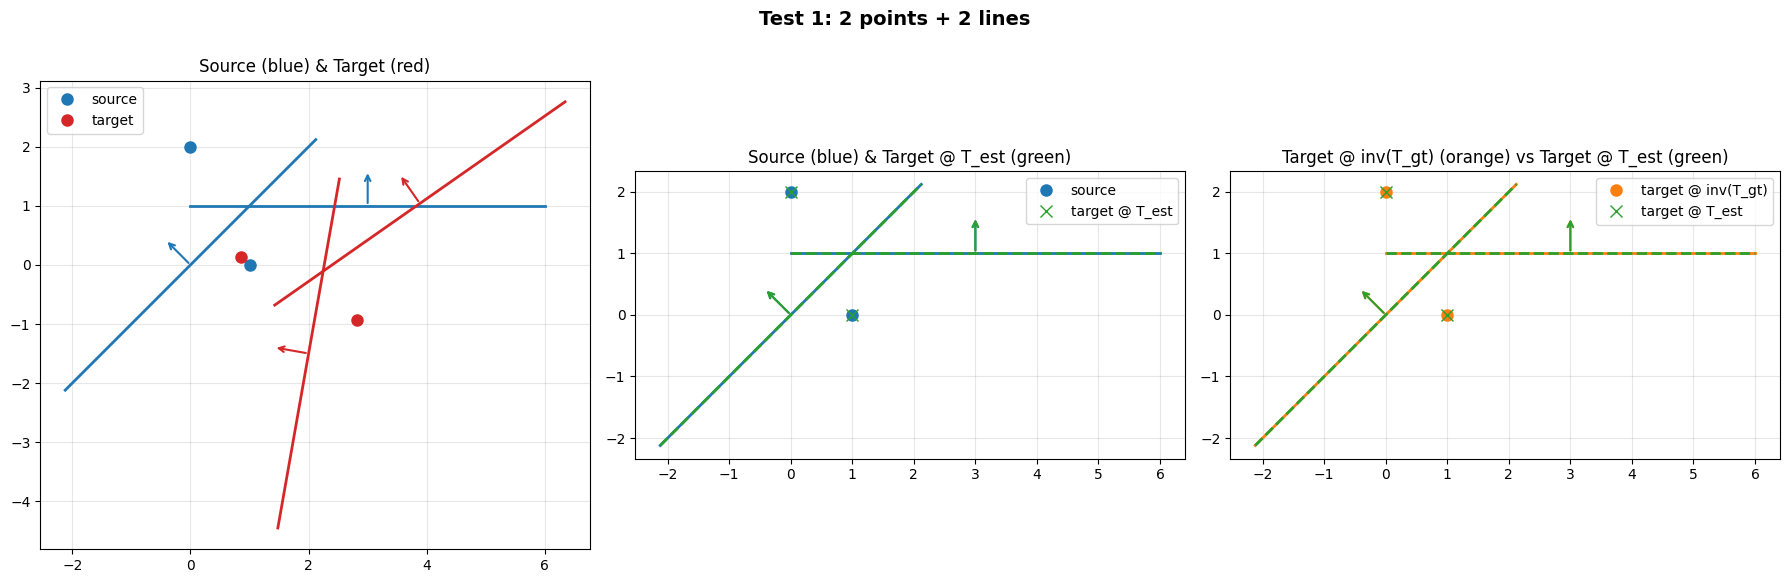

In [3]:
# Test 1: Two points + two lines (mixed)
T_gt = make_se2(35, 2.0, -1.5)
source = [
    SegmentPoint(id=0, point=np.array([1.0, 0.0])),
    SegmentPoint(id=1, point=np.array([0.0, 2.0])),
    SegmentLine(id=2, point=np.array([3.0, 1.0]), direction=np.array([1.0, 0.0])),
    SegmentLine(id=3, point=np.array([0.0, 0.0]), direction=np.array([1.0, 1.0])),
]
T_est, T_expected, err = run_registration(source, T_gt)
print(f"Test 1 (2 pts + 2 lines): max error = {err:.2e}")
visualize_registration(source, T_gt, T_est, title="Test 1: 2 points + 2 lines")

Test 2 (2 pts only): max error = 4.44e-16


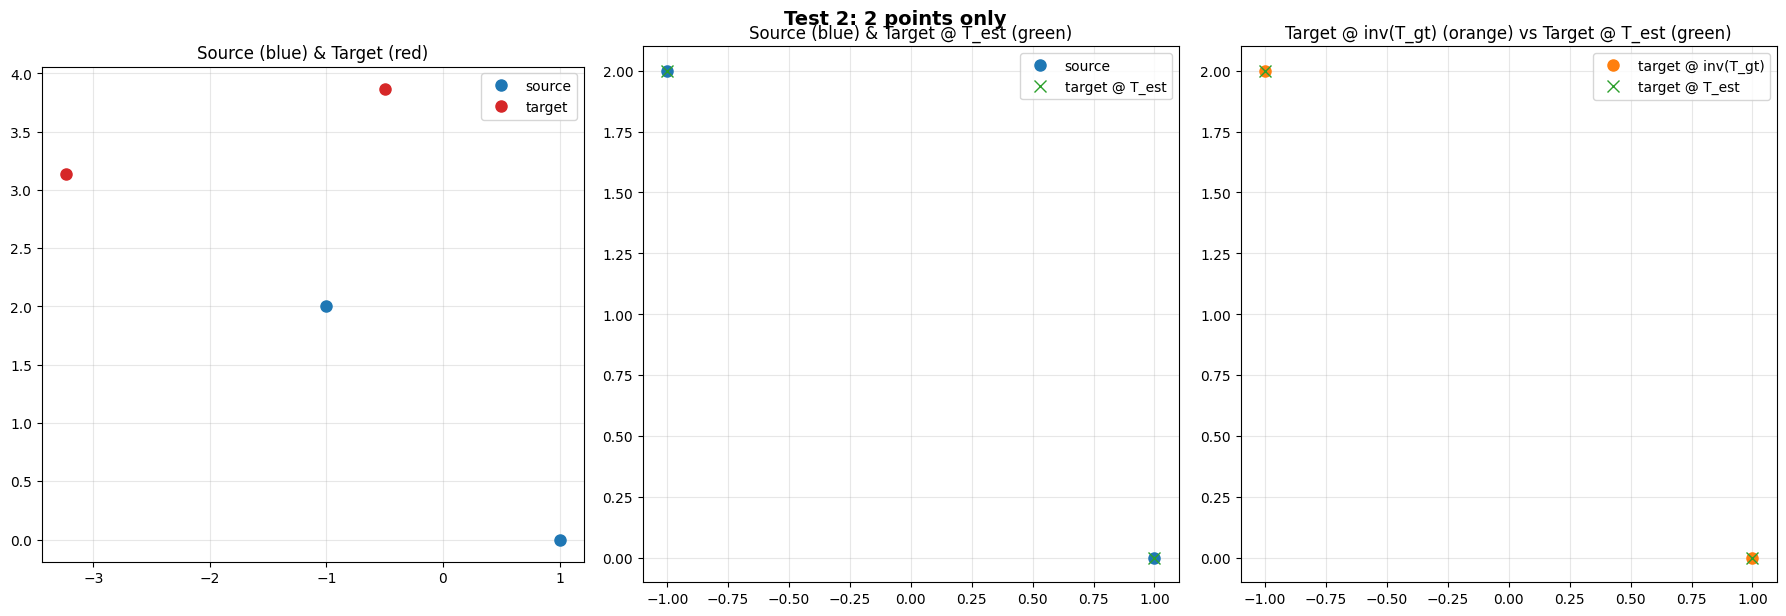

In [4]:
# Test 2: Two points only (no lines)
T_gt = make_se2(60, -1.0, 3.0)
source = [
    SegmentPoint(id=0, point=np.array([1.0, 0.0])),
    SegmentPoint(id=1, point=np.array([-1.0, 2.0])),
]
T_est, T_expected, err = run_registration(source, T_gt)
print(f"Test 2 (2 pts only): max error = {err:.2e}")
visualize_registration(source, T_gt, T_est, title="Test 2: 2 points only")

Test 3 (3 lines only): max error = 8.88e-16


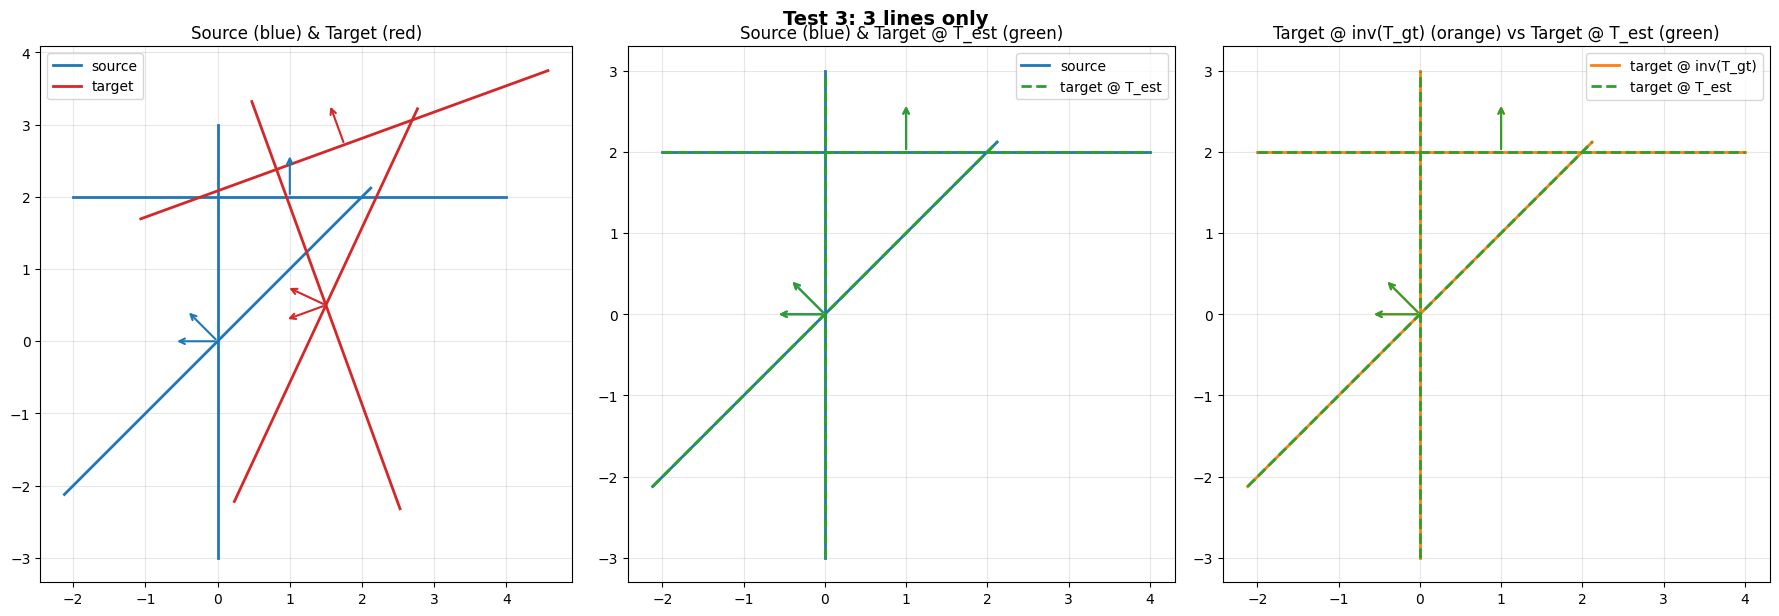

In [5]:
# Test 3: Three lines only (no points)
T_gt = make_se2(20, 1.5, 0.5)
source = [
    SegmentLine(id=0, point=np.array([1.0, 2.0]), direction=np.array([1.0, 0.0])),
    SegmentLine(id=1, point=np.array([0.0, 0.0]), direction=np.array([0.0, 1.0])),
    SegmentLine(id=2, point=np.array([0.0, 0.0]), direction=np.array([1.0, 1.0])),
]
T_est, T_expected, err = run_registration(source, T_gt)
print(f"Test 3 (3 lines only): max error = {err:.2e}")
visualize_registration(source, T_gt, T_est, title="Test 3: 3 lines only")

In [6]:
# Test 4: Degenerate - single point (insufficient)
T_gt = make_se2(45, 1.0, 1.0)
source = [SegmentPoint(id=0, point=np.array([1.0, 0.0]))]
try:
    run_registration(source, T_gt)
    print("Test 4 (1 pt): UNEXPECTED SUCCESS")
except (InsufficientAssociationsException, AssertionError) as e:
    print(f"Test 4 (1 pt): correctly rejected - {type(e).__name__}: {e}")

Test 4 (1 pt): correctly rejected - InsufficientAssociationsException: Insufficient for rotation: need at least 1 line or 2 non-identical points.


In [7]:
# Test 5: Degenerate - single line (rotation ok, translation underconstrained)
T_gt = make_se2(30, 1.0, 2.0)
source = [SegmentLine(id=0, point=np.array([1.0, 1.0]), direction=np.array([1.0, 0.0]))]
try:
    run_registration(source, T_gt)
    print("Test 5 (1 line): UNEXPECTED SUCCESS")
except (InsufficientAssociationsException, AssertionError) as e:
    print(f"Test 5 (1 line): correctly rejected - {type(e).__name__}: {e}")

Test 5 (1 line): correctly rejected - InsufficientAssociationsException: Insufficient for translation: need at least 1 point or 2 non-parallel lines.


In [8]:
# Test 6: Degenerate - two parallel lines (normals are collinear, rotation ambiguous)
T_gt = make_se2(15, 1.0, -1.0)
source = [
    SegmentLine(id=0, point=np.array([0.0, 0.0]), direction=np.array([1.0, 0.0])),
    SegmentLine(id=1, point=np.array([0.0, 3.0]), direction=np.array([1.0, 0.0])),
]
try:
    run_registration(source, T_gt)
    print("Test 6 (2 parallel lines): UNEXPECTED SUCCESS")
except (InsufficientAssociationsException, AssertionError) as e:
    print(f"Test 6 (2 parallel lines): correctly rejected - {type(e).__name__}: {e}")

Test 6 (2 parallel lines): correctly rejected - InsufficientAssociationsException: Insufficient for translation: need at least 1 point or 2 non-parallel lines.


In [9]:
# Test 6: Degenerate - two non-parallel lines (two possible rotations)
T_gt = make_se2(45, 1.0, -1.0)
source = [
    SegmentLine(id=0, point=np.array([0.0, 0.0]), direction=np.array([1.0, 0.0])),
    SegmentLine(id=1, point=np.array([3.0, 0.0]), direction=np.array([1.0, 1.0])),
]
try:
    run_registration(source, T_gt)
    print("Test 6 (2 lines): UNEXPECTED SUCCESS")
except (InsufficientAssociationsException, AssertionError) as e:
    print(f"Test 6 (2 lines): correctly rejected - {type(e).__name__}: {e}")

Test 6 (2 lines): correctly rejected - InsufficientAssociationsException: Degenerate configuration: both sign choices yield similar losses.


In [10]:
# Test 7: Degenerate - two coincident points (rotation unrecoverable)
T_gt = make_se2(90, 1.0, 1.0)
source = [
    SegmentPoint(id=0, point=np.array([2.0, 3.0])),
    SegmentPoint(id=1, point=np.array([2.0, 3.0])),
]
try:
    run_registration(source, T_gt)
    print("Test 7 (2 coincident pts): UNEXPECTED SUCCESS")
except (InsufficientAssociationsException, AssertionError) as e:
    print(f"Test 7 (2 coincident pts): correctly rejected - {type(e).__name__}: {e}")

Test 7 (2 coincident pts): correctly rejected - InsufficientAssociationsException: Insufficient for rotation: need at least 1 line or 2 non-identical points.


In [17]:
import time

# Test 8: BatchRegisterer2D
# Mix of valid and degenerate problems to verify batched output + failure counting.

params = RegisterParams()
batch_reg = BatchRegisterer2D(params)

np.random.seed(42)
N = 2000
sources_batch = []
targets_batch = []
expected_valid = []

for i in range(N):
    r = i % 10
    theta = np.random.uniform(-180, 180)
    tx, ty = np.random.uniform(-5, 5, size=2)
    T_gt_i = make_se2(theta, tx, ty)

    if r == 0 or r == 5:
        # 2 points + 2 lines (should succeed)
        src = [
            SegmentPoint(id=0, point=np.random.randn(2)),
            SegmentPoint(id=1, point=np.random.randn(2)),
            SegmentLine(id=2, point=np.random.randn(2), direction=np.random.randn(2)),
            SegmentLine(id=3, point=np.random.randn(2), direction=np.random.randn(2)),
        ]
        expected_valid.append(True)
    elif r == 1 or r == 6 or r == 9:
        # 3 points only (should succeed)
        src = [
            SegmentPoint(id=0, point=np.random.randn(2)),
            SegmentPoint(id=1, point=np.random.randn(2)),
            SegmentPoint(id=2, point=np.random.randn(2)),
        ]
        expected_valid.append(True)
    elif r == 2 or r == 7 or r == 8:
        # 2 points + 1 line (should succeed)
        src = [
            SegmentPoint(id=0, point=np.random.randn(2)),
            SegmentPoint(id=1, point=np.random.randn(2)),
            SegmentLine(id=2, point=np.random.randn(2), direction=np.random.randn(2)),
        ]
        expected_valid.append(True)
    elif r == 3:
        # 1 point only (should fail - can't solve rotation)
        src = [SegmentPoint(id=0, point=np.random.randn(2))]
        expected_valid.append(False)
    elif r == 4:
        # 2 coincident points (should fail - degenerate)
        pt = np.random.randn(2)
        src = [
            SegmentPoint(id=0, point=pt.copy()),
            SegmentPoint(id=1, point=pt.copy()),
        ]
        expected_valid.append(False)

    tgt = transform_segments(src, T_gt_i)
    sources_batch.append(src)
    targets_batch.append(tgt)

bs = time.time()
T_batch = batch_reg.register_batch(sources_batch, targets_batch)
bt = time.time() - bs

print(f"Output shape: {T_batch.shape}")

# Check valid results against single-registerer
single_reg = Registerer2D(params)
max_err = 0.0
n_checked = 0
nb_time = 0.0
for i in range(N):
    try:
        nbs = time.time()
        T_single = single_reg.register(sources_batch[i], targets_batch[i]).transformation
        nb_time += time.time() - nbs
    except InsufficientAssociationsException:
        pass

    if not expected_valid[i]:
        assert np.all(np.isnan(T_batch[i])), f"Problem {i} should be NaN but isn't"
        continue
    if np.any(np.isnan(T_batch[i])):
        continue
    err = np.max(np.abs(T_batch[i] - T_single))
    max_err = max(max_err, err)
    n_checked += 1

print(f"Checked {n_checked} valid problems against single registerer")
print(f"Max absolute error (batch vs single): {max_err:.2e}")

print(f"Batch registration of {N} problems took {bt:.6f} seconds")
print(f"Total time for single registration of {N} problems: {nb_time:.6f} seconds")

Batched 2D registration: 436/2000 failed
Output shape: (2000, 3, 3)
Checked 1564 valid problems against single registerer
Max absolute error (batch vs single): 7.11e-15
Batch registration of 2000 problems took 0.024419 seconds
Total time for single registration of 2000 problems: 0.074553 seconds
